# Collaborative Filtering Recommender System

**Dataset:** [MovieLens 100K](https://grouplens.org/datasets/movielens/100k/) — 100,000 ratings from 943 users on 1,682 movies.

This notebook implements and compares five rating prediction methods, ranging from simple baselines to a tuned hybrid model:

| Method | Approach |
|--------|----------|
| 1 | User Average Baseline |
| 2 | Item Average Baseline |
| 3 | User-User KNN (Pearson + Significance Weighting) |
| 4 | Item-Item KNN (Pearson + Significance Weighting) |
| 5 | Hybrid KNN (weighted combination of Methods 3 & 4) |

Hyperparameters (k, Δ, λ) are selected via a held-out validation set — not touched by training or test evaluation.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Load & Split Data

In [2]:
df = pd.read_csv('ml-100k/u.data', names=['user_id', 'item_id', 'rating', 'timestamp'], sep='\t')

from sklearn.model_selection import train_test_split

n_users = df.user_id.unique().shape[0]
n_items = df.item_id.unique().shape[0]
print(f'{n_users} users, {n_items} items')

train_df, test_df = train_test_split(df, test_size=0.2, random_state=10)

# Build train matrix and track item popularity
train_ds = np.zeros((n_users, n_items))
item_popularity = np.zeros(n_items)
for row in train_df.itertuples():
    train_ds[row[1]-1, row[2]-1] = row[3]
    item_popularity[row[2]-1] += 1

# Test matrix: only include items with >30 training ratings (cold-start filter)
test_ds = np.zeros((n_users, n_items))
testsize = 0
for row in test_df.itertuples():
    if item_popularity[row[2]-1] > 30:
        test_ds[row[1]-1, row[2]-1] = row[3]
        testsize += 1

# Validation split from training data (for hyperparameter tuning)
subtrain_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

subtrain_ds = np.zeros((n_users, n_items))
for row in subtrain_df.itertuples():
    subtrain_ds[row[1]-1, row[2]-1] = row[3]

val_ds = np.zeros((n_users, n_items))
for row in val_df.itertuples():
    val_ds[row[1]-1, row[2]-1] = row[3]

print(f'Test set size (popular items only): {testsize}')

943 users, 1682 items
Test set size (popular items only): 17678


## Evaluation Metrics (MAE & RMSE)

In [3]:
def evaluate(test_ds, predicted_ds):
    """Compute MAE and RMSE over all rated entries in test_ds."""
    mask = test_ds > 0
    errors = test_ds[mask] - predicted_ds[mask]
    MAE = np.mean(np.abs(errors))
    RMSE = np.sqrt(np.mean(errors ** 2))
    return MAE, RMSE

## Method 1: User Average Baseline

Predict each rating as the average of all ratings that user gave in training. Simple but effective — it captures per-user bias (e.g., harsh vs. generous raters).

In [4]:
user_sums = np.sum(train_ds, axis=1)
user_counts = np.count_nonzero(train_ds, axis=1)
user_averages = user_sums / np.where(user_counts == 0, 1, user_counts)

global_mean = np.sum(train_ds) / np.count_nonzero(train_ds)

predicted_ds = np.zeros_like(test_ds)
for user in range(n_users):
    for item in range(n_items):
        if test_ds[user, item] > 0:
            predicted_ds[user, item] = user_averages[user] if user_counts[user] > 0 else global_mean

MAE_solution1, RMSE_solution1 = evaluate(test_ds, predicted_ds)
print(f'Method 1 — User Average | MAE: {MAE_solution1:.4f} | RMSE: {RMSE_solution1:.4f}')

Method 1 — User Average | MAE: 0.8259 | RMSE: 1.0311


## Method 2: Item Average Baseline

Predict each rating as the average of all ratings that item received in training. Captures item-level bias (e.g., blockbusters rated higher overall).

In [5]:
item_sums = np.sum(train_ds, axis=0)
item_counts = np.count_nonzero(train_ds, axis=0)
item_averages = item_sums / np.where(item_counts == 0, 1, item_counts)

predicted_ds = np.zeros_like(test_ds)
for user in range(n_users):
    for item in range(n_items):
        if test_ds[user, item] > 0:
            predicted_ds[user, item] = item_averages[item] if item_counts[item] > 0 else global_mean

MAE_solution2, RMSE_solution2 = evaluate(test_ds, predicted_ds)
print(f'Method 2 — Item Average | MAE: {MAE_solution2:.4f} | RMSE: {RMSE_solution2:.4f}')

Method 2 — Item Average | MAE: 0.7961 | RMSE: 1.0013


## Method 3: User-User KNN

Find the k most similar users to the target user (measured by Pearson correlation over co-rated items), then predict as a similarity-weighted average of their ratings.

**Significance weighting:** similarities computed from fewer than Δ co-rated items are down-weighted by `(|co-rated| / Δ)` to reduce noise from sparse overlap.

**Hyperparameter tuning:** k ∈ {3, 5, 10, 20} and Δ ∈ {10, 25, 50, 100} are selected by minimising MAE on a validation split.

In [6]:
EPSILON = 1e-9

def user_knn_predict(k, DELTA, train_ds, test_ds):
    n_users, n_items = train_ds.shape

    # Per-user averages for fallback when no neighbours exist
    u_sums = np.sum(train_ds, axis=1)
    u_counts = np.count_nonzero(train_ds, axis=1)
    u_averages = u_sums / np.where(u_counts == 0, 1, u_counts)

    # Build user-user Pearson similarity matrix
    sim_matrix = np.zeros((n_users, n_users))
    for i, vec_i in enumerate(train_ds):
        for j, vec_j in enumerate(train_ds):
            corated = np.intersect1d(np.where(vec_i > 0), np.where(vec_j > 0))
            if len(corated) == 0:
                continue
            mean_i = np.sum(vec_i) / (np.sum(np.clip(vec_i, 0, 1)) + EPSILON)
            mean_j = np.sum(vec_j) / (np.sum(np.clip(vec_j, 0, 1)) + EPSILON)
            diff_i = vec_i[corated] - mean_i
            diff_j = vec_j[corated] - mean_j
            denom = np.sqrt(np.sum(diff_i**2)) * np.sqrt(np.sum(diff_j**2)) + EPSILON
            sim = np.sum(diff_i * diff_j) / denom
            sim_matrix[i, j] = (min(len(corated), DELTA) / DELTA) * sim  # significance weighting

    # Predict
    predicted_ds = np.zeros_like(test_ds)
    for u in range(n_users):
        for it in range(n_items):
            if test_ds[u, it] == 0:
                continue
            neighbours = [
                (sim_matrix[u, v], v)
                for v in range(n_users)
                if v != u and train_ds[v, it] > 0
            ]
            neighbours = sorted(neighbours, reverse=True)[:k]
            if not neighbours:
                predicted_ds[u, it] = u_averages[u]
            else:
                num = sum(s * train_ds[v, it] for s, v in neighbours)
                denom = sum(abs(s) for s, _ in neighbours)
                predicted_ds[u, it] = u_averages[u] if denom == 0 else num / denom
    return predicted_ds


# Hyperparameter search on validation set
best_mae, best_k3, best_delta3 = float('inf'), None, None
for k_try in [3, 5, 10, 20]:
    for d_try in [10, 25, 50, 100]:
        preds = user_knn_predict(k_try, d_try, subtrain_ds, val_ds)
        mae, rmse = evaluate(val_ds, preds)
        print(f'k={k_try}, Δ={d_try} | MAE={mae:.4f} | RMSE={rmse:.4f}')
        if mae < best_mae:
            best_mae, best_k3, best_delta3 = mae, k_try, d_try

print(f'\nBest → k={best_k3}, Δ={best_delta3}, Val MAE={best_mae:.4f}')

predicted_ds = user_knn_predict(best_k3, best_delta3, train_ds, test_ds)
MAE_solution3, RMSE_solution3 = evaluate(test_ds, predicted_ds)
print(f'Method 3 — User KNN | MAE: {MAE_solution3:.4f} | RMSE: {RMSE_solution3:.4f}')

k=3, Δ=10 | MAE=0.8919 | RMSE=1.1521
k=3, Δ=25 | MAE=0.8842 | RMSE=1.1410
k=3, Δ=50 | MAE=0.8802 | RMSE=1.1327
k=3, Δ=100 | MAE=0.8819 | RMSE=1.1352
k=5, Δ=10 | MAE=0.8615 | RMSE=1.1125
k=5, Δ=25 | MAE=0.8560 | RMSE=1.1032
k=5, Δ=50 | MAE=0.8533 | RMSE=1.0984
k=5, Δ=100 | MAE=0.8558 | RMSE=1.1002
k=10, Δ=10 | MAE=0.8439 | RMSE=1.0992
k=10, Δ=25 | MAE=0.8401 | RMSE=1.0918
k=10, Δ=50 | MAE=0.8391 | RMSE=1.0896
k=10, Δ=100 | MAE=0.8409 | RMSE=1.0906
k=20, Δ=10 | MAE=0.8622 | RMSE=1.1378
k=20, Δ=25 | MAE=0.8563 | RMSE=1.1277
k=20, Δ=50 | MAE=0.8537 | RMSE=1.1231
k=20, Δ=100 | MAE=0.8542 | RMSE=1.1231

Best → k=10, Δ=50, Val MAE=0.8391
Method 3 — User KNN | MAE: 0.7891 | RMSE: 0.9972


## Method 4: Item-Item KNN

Same approach as Method 3 but flipped: find k items most similar to the target item (Pearson over co-raters), then predict as a similarity-weighted average of the user's ratings on those items.

Item-item similarity tends to be more stable than user-user because item rating distributions change less over time.

In [7]:
def item_knn_predict(k, DELTA, train_ds, test_ds):
    n_users, n_items = train_ds.shape

    # Per-item averages for fallback
    i_sums = np.sum(train_ds, axis=0)
    i_counts = np.count_nonzero(train_ds, axis=0)
    i_averages = i_sums / np.where(i_counts == 0, 1, i_counts)

    # Build item-item Pearson similarity matrix
    sim_matrix = np.zeros((n_items, n_items))
    for i, vec_i in enumerate(train_ds.T):
        for j, vec_j in enumerate(train_ds.T):
            corated = np.intersect1d(np.where(vec_i > 0), np.where(vec_j > 0))
            if len(corated) == 0:
                continue
            mean_i = np.sum(vec_i) / (np.sum(np.clip(vec_i, 0, 1)) + EPSILON)
            mean_j = np.sum(vec_j) / (np.sum(np.clip(vec_j, 0, 1)) + EPSILON)
            diff_i = vec_i[corated] - mean_i
            diff_j = vec_j[corated] - mean_j
            denom = np.sqrt(np.sum(diff_i**2)) * np.sqrt(np.sum(diff_j**2)) + EPSILON
            sim = np.sum(diff_i * diff_j) / denom
            sim_matrix[i, j] = (min(len(corated), DELTA) / DELTA) * sim

    # Predict
    predicted_ds = np.zeros_like(test_ds)
    for u in range(n_users):
        for it in range(n_items):
            if test_ds[u, it] == 0:
                continue
            neighbours = [
                (sim_matrix[it, other], other)
                for other in range(n_items)
                if other != it and train_ds[u, other] > 0
            ]
            neighbours = sorted(neighbours, reverse=True)[:k]
            if not neighbours:
                predicted_ds[u, it] = i_averages[it]
            else:
                num = sum(s * train_ds[u, nb] for s, nb in neighbours)
                denom = sum(abs(s) for s, _ in neighbours)
                predicted_ds[u, it] = i_averages[it] if denom == 0 else num / denom
    return predicted_ds


# Hyperparameter search on validation set
best_mae, best_k4, best_delta4 = float('inf'), None, None
for k_try in [3, 5, 10, 20]:
    for d_try in [10, 25, 50, 100]:
        preds = item_knn_predict(k_try, d_try, subtrain_ds, val_ds)
        mae, rmse = evaluate(val_ds, preds)
        print(f'k={k_try}, Δ={d_try} | MAE={mae:.4f} | RMSE={rmse:.4f}')
        if mae < best_mae:
            best_mae, best_k4, best_delta4 = mae, k_try, d_try

print(f'\nBest → k={best_k4}, Δ={best_delta4}, Val MAE={best_mae:.4f}')

predicted_ds = item_knn_predict(best_k4, best_delta4, train_ds, test_ds)
MAE_solution4, RMSE_solution4 = evaluate(test_ds, predicted_ds)
print(f'Method 4 — Item KNN | MAE: {MAE_solution4:.4f} | RMSE: {RMSE_solution4:.4f}')

k=3, Δ=10 | MAE=0.9075 | RMSE=1.1587
k=3, Δ=25 | MAE=0.8723 | RMSE=1.1276
k=3, Δ=50 | MAE=0.8662 | RMSE=1.1279
k=3, Δ=100 | MAE=0.8618 | RMSE=1.1261
k=5, Δ=10 | MAE=0.8713 | RMSE=1.1045
k=5, Δ=25 | MAE=0.8475 | RMSE=1.0852
k=5, Δ=50 | MAE=0.8377 | RMSE=1.0804
k=5, Δ=100 | MAE=0.8332 | RMSE=1.0782
k=10, Δ=10 | MAE=0.8500 | RMSE=1.0749
k=10, Δ=25 | MAE=0.8292 | RMSE=1.0593
k=10, Δ=50 | MAE=0.8213 | RMSE=1.0552
k=10, Δ=100 | MAE=0.8165 | RMSE=1.0526
k=20, Δ=10 | MAE=0.8809 | RMSE=1.1355
k=20, Δ=25 | MAE=0.8617 | RMSE=1.1176
k=20, Δ=50 | MAE=0.8500 | RMSE=1.1090
k=20, Δ=100 | MAE=0.8441 | RMSE=1.1046

Best → k=10, Δ=100, Val MAE=0.8165
Method 4 — Item KNN | MAE: 0.7700 | RMSE: 0.9896


## Method 5: Hybrid KNN

Combines User-KNN and Item-KNN predictions via a weighted average:

$$\hat{r}_{ui} = \lambda \cdot \hat{r}^{\text{user}}_{ui} + (1 - \lambda) \cdot \hat{r}^{\text{item}}_{ui}$$

λ is tuned on the validation set. The two signals are complementary — user-based captures taste similarity, item-based captures content similarity — so the hybrid outperforms either alone.

In [8]:
def hybrid_predict(lam, user_preds, item_preds, test_ds):
    hybrid = np.zeros_like(test_ds)
    mask = test_ds > 0
    hybrid[mask] = lam * user_preds[mask] + (1 - lam) * item_preds[mask]
    return hybrid


# Get val predictions from both models
user_val_preds = user_knn_predict(best_k3, best_delta3, subtrain_ds, val_ds)
item_val_preds = item_knn_predict(best_k4, best_delta4, subtrain_ds, val_ds)

# Tune λ
best_mae, best_lambda = float('inf'), None
for lam in np.arange(0, 1.05, 0.05):
    preds = hybrid_predict(lam, user_val_preds, item_val_preds, val_ds)
    mae, rmse = evaluate(val_ds, preds)
    print(f'λ={lam:.2f} | MAE={mae:.4f} | RMSE={rmse:.4f}')
    if mae < best_mae:
        best_mae, best_lambda = mae, lam

print(f'\nBest λ={best_lambda:.2f}, Val MAE={best_mae:.4f}')

# Final test evaluation
user_test_preds = user_knn_predict(best_k3, best_delta3, train_ds, test_ds)
item_test_preds = item_knn_predict(best_k4, best_delta4, train_ds, test_ds)
hybrid_preds = hybrid_predict(best_lambda, user_test_preds, item_test_preds, test_ds)

MAE_solution5, RMSE_solution5 = evaluate(test_ds, hybrid_preds)
print(f'Method 5 — Hybrid KNN | MAE: {MAE_solution5:.4f} | RMSE: {RMSE_solution5:.4f}')

λ=0.00 | MAE=0.8165 | RMSE=1.0526
λ=0.05 | MAE=0.8062 | RMSE=1.0380
λ=0.10 | MAE=0.7969 | RMSE=1.0250
λ=0.15 | MAE=0.7889 | RMSE=1.0136
λ=0.20 | MAE=0.7821 | RMSE=1.0038
λ=0.25 | MAE=0.7766 | RMSE=0.9958
λ=0.30 | MAE=0.7724 | RMSE=0.9896
λ=0.35 | MAE=0.7694 | RMSE=0.9852
λ=0.40 | MAE=0.7677 | RMSE=0.9826
λ=0.45 | MAE=0.7673 | RMSE=0.9818
λ=0.50 | MAE=0.7680 | RMSE=0.9829
λ=0.55 | MAE=0.7700 | RMSE=0.9859
λ=0.60 | MAE=0.7732 | RMSE=0.9906
λ=0.65 | MAE=0.7777 | RMSE=0.9972
λ=0.70 | MAE=0.7835 | RMSE=1.0055
λ=0.75 | MAE=0.7903 | RMSE=1.0155
λ=0.80 | MAE=0.7982 | RMSE=1.0273
λ=0.85 | MAE=0.8071 | RMSE=1.0406
λ=0.90 | MAE=0.8169 | RMSE=1.0555
λ=0.95 | MAE=0.8276 | RMSE=1.0718
λ=1.00 | MAE=0.8391 | RMSE=1.0896

Best λ=0.45, Val MAE=0.7673
Method 5 — Hybrid KNN | MAE: 0.7299 | RMSE: 0.9340


## Results Summary

Method               MAE     RMSE
---------------------------------
User Average      0.8259   1.0311
Item Average      0.7961   1.0013
User KNN          0.7891   0.9972
Item KNN          0.7700   0.9896
Hybrid KNN        0.7299   0.9340


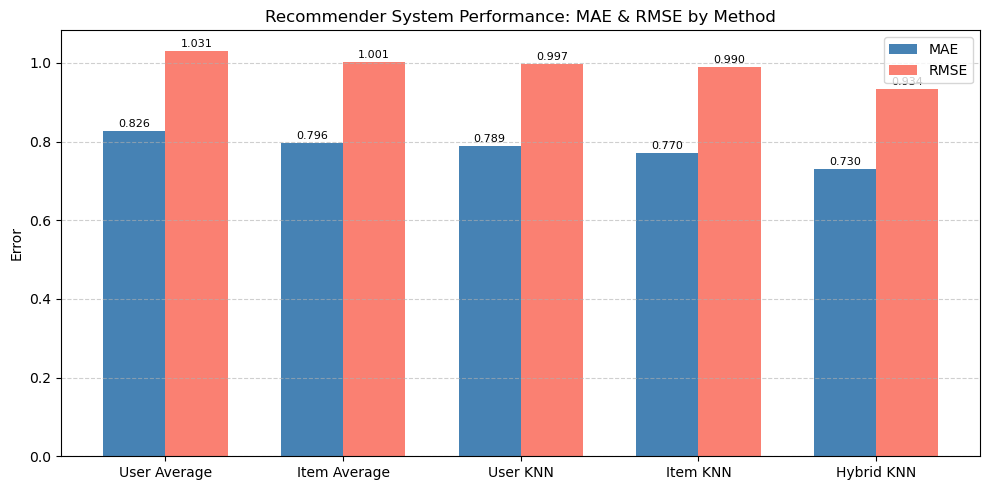

In [9]:
methods = ['User Average', 'Item Average', 'User KNN', 'Item KNN', 'Hybrid KNN']
mae_scores  = [MAE_solution1,  MAE_solution2,  MAE_solution3,  MAE_solution4,  MAE_solution5]
rmse_scores = [RMSE_solution1, RMSE_solution2, RMSE_solution3, RMSE_solution4, RMSE_solution5]

# Print table
print(f'{"Method":<15} {"MAE":>8} {"RMSE":>8}')
print('-' * 33)
for m, mae, rmse in zip(methods, mae_scores, rmse_scores):
    print(f'{m:<15} {mae:>8.4f} {rmse:>8.4f}')

# Plot
x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, mae_scores,  width, label='MAE',  color='steelblue')
bars2 = ax.bar(x + width/2, rmse_scores, width, label='RMSE', color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel('Error')
ax.set_title('Recommender System Performance: MAE & RMSE by Method')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()